In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import json
from collections import defaultdict

FONTSIZE  = 32
LINEWIDTH = 3

plt.rcParams.update({
    "font.size":             FONTSIZE,
    "axes.labelsize":        FONTSIZE,
    "axes.titlesize":        FONTSIZE,
    "xtick.labelsize":       FONTSIZE - 4,
    "ytick.labelsize":       FONTSIZE - 4,
    "legend.fontsize":       FONTSIZE - 8,
    "legend.title_fontsize": FONTSIZE - 6,
    "axes.linewidth":        1.5,
    "xtick.major.width":     1.5,
    "ytick.major.width":     1.5,
    "xtick.major.size":      6,
    "ytick.major.size":      6,
})

In [23]:
# ── Config ────────────────────────────────────────────────────────────────────
DATA_DIR = '../data'
MODEL    = 'complete_model_extreme_fav'
SMOOTH   = 5

FAVILA_DIR     = os.path.join(DATA_DIR, 'favila2016_nopred',            MODEL)
CHANALES21_DIR = os.path.join(DATA_DIR, 'chanales2021_exp1_v3',  MODEL)
CHANALES17_DIR = os.path.join(DATA_DIR, 'chanales2017_sim1',     MODEL)

# Chanales 2021 conditions
C21_CONDITIONS = {
    'ultra_sim': 'ultra',
    'high_sim': 'high',
    'med_sim':  'mod.',
    'low_sim':  'low',
}
C21_COLORS = {
    'ultra_sim': 'tab:green',
    'high_sim': 'tab:red',
    'med_sim':  '#FFD700',
    'low_sim':  'tab:blue',
}

# Chanales 2017 network colors (as specified)
C17_NET_COLORS = {0: '#e5e289', 1: '#89e590'}

# Favila subgroup colors (from favila_analysis.ipynb)
FAVILA_SG_COLORS = {
    'no face':        'grey',
    'diff. face': 'red',
    'same face':      'blue',
}

# Network labels (used across all panels)
NET_LABELS = {0: 'Dense\nnetwork', 1: 'Sparse\nnetwork'}

In [24]:
# ── Favila helpers (from favila_analysis.ipynb) ───────────────────────────────

def within_minus_between_similarity(representations, rows_meta):
    subgroups = list(dict.fromkeys(r['subgroup'] for r in rows_meta))
    indices_by_sg = {
        sg: np.array([i for i, r in enumerate(rows_meta) if r['subgroup'] == sg])
        for sg in subgroups
    }
    group_ids_by_sg = {
        sg: np.array([rows_meta[i]['group_id'] for i in idxs])
        for sg, idxs in indices_by_sg.items()
    }
    result = {}
    for sg in subgroups:
        idxs      = indices_by_sg[sg]
        group_ids = group_ids_by_sg[sg]
        same_group = group_ids[:, None] == group_ids[None, :]
        np.fill_diagonal(same_group, False)
        diff_group = ~same_group
        np.fill_diagonal(diff_group, False)
        scores = np.empty(representations.shape[0])
        for t in range(representations.shape[0]):
            reps   = representations[t][idxs]
            cosim  = np.corrcoef(reps, rowvar=True)
            within  = cosim[same_group].mean() if same_group.any() else 0.0
            between = cosim[diff_group].mean() if diff_group.any() else 0.0
            scores[t] = within - between
        result[sg] = scores
    return result


def _detect_networks(run_dir, probe_name, layer_key):
    prefix = f'{probe_name}_net'
    suffix = f'_{layer_key}.npy'
    return sorted(
        int(f[len(prefix):-len(suffix)])
        for f in os.listdir(run_dir)
        if f.startswith(prefix) and f.endswith(suffix)
           and f[len(prefix):-len(suffix)].isdigit()
    )


def _load_run(run_dir, probe_name, layer_key, net_indices):
    with open(os.path.join(run_dir, f'{probe_name}_rows.json')) as f:
        rows_meta = json.load(f)
    steps = np.load(os.path.join(run_dir, f'{probe_name}_steps.npy'))
    reps_by_net = {
        ni: np.load(os.path.join(run_dir, f'{probe_name}_net{ni}_{layer_key}.npy'))
        for ni in net_indices
    }
    return reps_by_net, rows_meta, steps


def plot_favila_panel(multirun_dir, net_idx, ax, title=None,
                      probe='representations', layer='hidden_0'):
    """Favila within-minus-between similarity for one network stream."""
    run_dirs = sorted([
        os.path.join(multirun_dir, d)
        for d in os.listdir(multirun_dir)
        if os.path.isdir(os.path.join(multirun_dir, d))
           and os.path.isfile(os.path.join(multirun_dir, d, f'{probe}_rows.json'))
    ])
    net_indices = _detect_networks(run_dirs[0], probe, layer)

    all_scores, steps_ref = {}, None
    for run_dir in run_dirs:
        reps_by_net, rows_meta, steps = _load_run(run_dir, probe, layer, net_indices)
        if steps_ref is None:
            steps_ref = steps
        for sg, arr in within_minus_between_similarity(reps_by_net[net_idx], rows_meta).items():
            all_scores.setdefault(sg, []).append(arr)

    for sg, arrays in all_scores.items():
        mat   = np.stack(arrays)
        mean  = mat.mean(axis=0)
        sem   = mat.std(axis=0) / np.sqrt(len(arrays))
        label = sg.replace('_', ' ')
        label = label.replace('different', 'diff.')
        color = FAVILA_SG_COLORS.get(label)
        ax.plot(steps_ref, mean, label=label, color=color, lw=LINEWIDTH)
        ax.fill_between(steps_ref, mean - sem, mean + sem, alpha=0.2, color=color)

    ax.axhline(0, color='0.5', linestyle='--', linewidth=2, zorder=1)
    ax.set_xlabel('Trials')
    ax.set_ylabel('Pair similarity')
    if title:
        ax.set_title(title)
    ax.legend(frameon=False, loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0)

In [25]:
# ── Chanales 2021 helpers (from chanales2021_analysis.ipynb) ──────────────────

def _signed_angle(origin, target, x):
    e1 = origin / np.linalg.norm(origin)
    v  = target - np.dot(target, e1) * e1
    e2 = v / np.linalg.norm(v)
    def _angle(y):
        return np.arctan2(np.dot(y, e2), np.dot(y, e1))
    wrap = lambda a: (a + np.pi) % (2 * np.pi) - np.pi
    return -np.degrees(np.sign(wrap(_angle(target) - _angle(origin))) * wrap(_angle(x) - _angle(origin)))


def _do_smooth(arr, w):
    if w is None or w <= 1:
        return arr
    return np.convolve(arr, np.ones(w) / w, mode='valid')


def plot_chanales21_panel(multirun_dir, conditions, colors, ax,
                           smooth=SMOOTH, probe='prediction', slot='color'):
    """Chanales 2021 proportion-positive repulsion, all trials."""
    if isinstance(conditions, list):
        conditions = {sg: sg for sg in conditions}
    if isinstance(colors, list):
        colors = {sg: c for sg, c in zip(conditions, colors)}

    seed_dirs_list = sorted([
        os.path.join(multirun_dir, d)
        for d in os.listdir(multirun_dir)
        if os.path.isdir(os.path.join(multirun_dir, d))
    ], key=lambda p: int(os.path.basename(p)) if os.path.basename(p).isdigit() else float('inf'))

    cond_metrics = {sg: [] for sg in conditions}
    common_steps = None

    for sd in seed_dirs_list:
        pred_f  = os.path.join(sd, f'{probe}_combined_{slot}.npy')
        gt_f    = os.path.join(sd, f'{probe}_target_{slot}.npy')
        rows_f  = os.path.join(sd, f'{probe}_rows.json')
        steps_f = os.path.join(sd, f'{probe}_steps.npy')
        if not all(os.path.exists(p) for p in (pred_f, gt_f, rows_f, steps_f)):
            continue
        prediction   = np.load(pred_f)
        ground_truth = np.load(gt_f)
        steps_arr    = np.load(steps_f)
        with open(rows_f) as f:
            row_info = json.load(f)
        if common_steps is None:
            common_steps = steps_arr
        n_groups = ground_truth.shape[0] // 2
        metric   = np.empty((len(steps_arr), len(row_info)))
        for t in range(len(steps_arr)):
            vals = []
            for i in range(n_groups):
                gt1, gt2     = ground_truth[2*i], ground_truth[2*i+1]
                pred1, pred2 = prediction[t, 2*i], prediction[t, 2*i+1]
                vals.extend([_signed_angle(gt1, gt2, pred1), _signed_angle(gt2, gt1, pred2)])
            metric[t] = vals
        for sg in conditions:
            mask = np.array([r['subgroup'] == sg for r in row_info])
            if mask.any():
                cond_metrics[sg].append(metric[:, mask])

    x = common_steps[(smooth - 1):]
    z = 1.96

    for sg, label in conditions.items():
        metrics = cond_metrics[sg]
        if not metrics:
            continue
        pooled    = np.concatenate(metrics, axis=1)
        successes = (pooled > 0).sum(axis=1)
        n         = (np.isfinite(pooled) & (pooled != 0)).sum(axis=1)
        p         = successes / n
        denom     = 1 + z**2 / n
        centre    = (p + z**2 / (2*n)) / denom
        half      = z * np.sqrt(p*(1-p)/n + z**2/(4*n**2)) / denom
        colour    = colors.get(sg)
        ax.plot(x, _do_smooth(centre, smooth), color=colour, label=label, lw=LINEWIDTH)
        ax.fill_between(x, _do_smooth(centre - half, smooth),
                           _do_smooth(centre + half, smooth), alpha=0.2, color=colour)

    ax.axhline(0.5, color='0.5', linestyle='--', linewidth=2, zorder=1)
    ax.set_ylim(0, 1)
    ax.set_xlabel('Trials')
    ax.set_ylabel('Responses Away\nFrom Competitor')
    ax.legend(frameon=False, loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0)

In [26]:
# ── Chanales 2017 helpers (from chanales_2017b_analysis.ipynb) ────────────────

def _compute_sim_diff(reps, rows):
    groups = defaultdict(list)
    for i, r in enumerate(rows):
        groups[(r['subgroup'], r['group_id'])].append(i)
    group_lists = list(groups.values())
    within_sims, between_sims = [], []
    for t in range(reps.shape[0]):
        sim = np.corrcoef(reps[t])
        w, b = [], []
        for gi, g1 in enumerate(group_lists):
            for a in range(len(g1)):
                for b_ in range(a + 1, len(g1)):
                    w.append(sim[g1[a], g1[b_]])
            for g2 in group_lists[gi + 1:]:
                for i1 in g1:
                    for i2 in g2:
                        b.append(sim[i1, i2])
        within_sims.append(np.mean(w))
        between_sims.append(np.mean(b))
    return np.array(within_sims) - np.array(between_sims)


def plot_chanales17_panel(multirun_dir, nets=(0, 1), layer='hidden_0',
                           probe='representations', smooth=SMOOTH, ax=None):
    """Chanales 2017 within-minus-between similarity, both networks."""
    run_dirs_list = sorted([
        os.path.join(multirun_dir, d)
        for d in os.listdir(multirun_dir)
        if os.path.isdir(os.path.join(multirun_dir, d))
    ])
    trajectories = {ni: [] for ni in nets}
    common_steps = None
    for sd in run_dirs_list:
        for ni in nets:
            try:
                reps  = np.load(os.path.join(sd, f'{probe}_net{ni}_{layer}.npy'))
                steps = np.load(os.path.join(sd, f'{probe}_steps.npy'))
                with open(os.path.join(sd, f'{probe}_rows.json')) as f:
                    rows = json.load(f)
            except FileNotFoundError:
                continue
            if common_steps is None:
                common_steps = steps
            trajectories[ni].append(_compute_sim_diff(reps, rows))

    x = common_steps[(smooth - 1):]
    for ni in nets:
        trajs = trajectories[ni]
        if not trajs:
            continue
        arr   = np.stack(trajs)
        mean  = _do_smooth(arr.mean(axis=0), smooth)
        sem   = _do_smooth(arr.std(axis=0) / np.sqrt(len(trajs)), smooth)
        color = C17_NET_COLORS[ni]
        label = NET_LABELS[ni]
        ax.plot(x, mean, color=color, label=label, lw=LINEWIDTH)
        ax.fill_between(x, mean - sem, mean + sem, alpha=0.2, color=color)

    ax.axhline(0, color='0.5', linestyle='--', linewidth=2, zorder=1)
    ax.set_xlabel('Trials')
    ax.set_ylabel('Pair similarity')
    ax.legend(frameon=False, loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0)

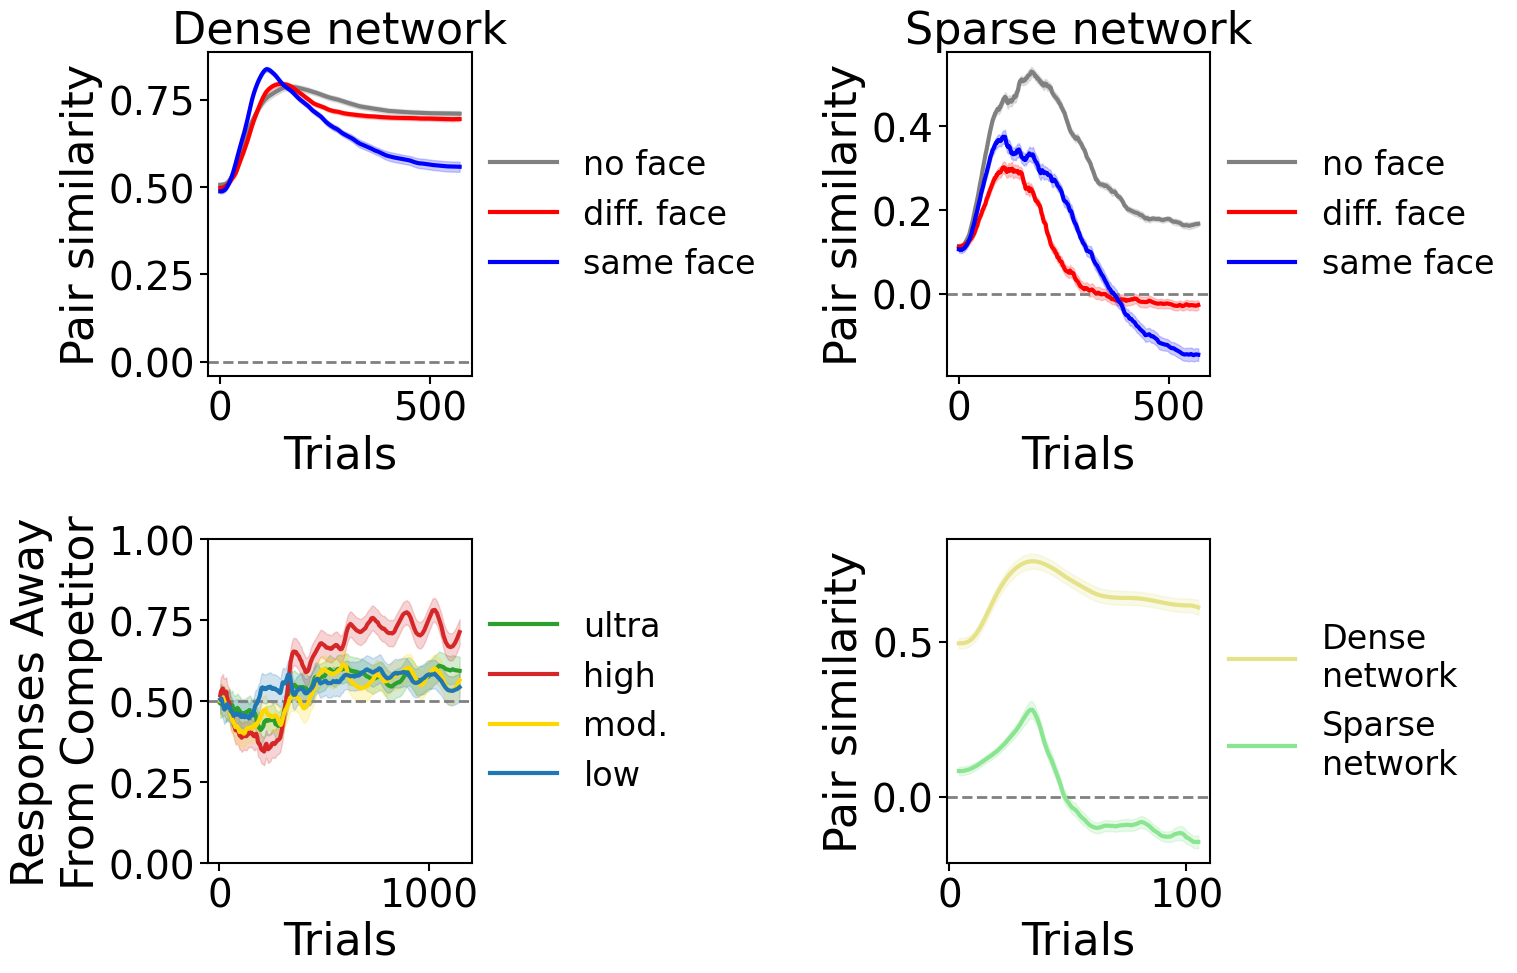

In [28]:
# ── Assemble figure ───────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(16, 10.5))
((ax_tl, ax_tr), (ax_bl, ax_br)) = axes

# Top-left:  Favila — Dense network (net 0)
plot_favila_panel(FAVILA_DIR, net_idx=0, ax=ax_tl, title='Dense network')

# Top-right: Favila — Sparse network (net 1)
plot_favila_panel(FAVILA_DIR, net_idx=1, ax=ax_tr, title='Sparse network')

# Bottom-left:  Chanales 2021, proportion positive, all trials
plot_chanales21_panel(CHANALES21_DIR, C21_CONDITIONS, C21_COLORS, ax=ax_bl)

# Bottom-right: Chanales 2017, both networks
plot_chanales17_panel(CHANALES17_DIR, ax=ax_br)

plt.tight_layout()
os.makedirs('../figures', exist_ok=True)
plt.savefig('../figures/poster_figure.pdf', bbox_inches='tight', dpi=300)
plt.show()